In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
orders = pd.read_csv("orders_clean (1).csv")
sellers = pd.read_csv("sellers_clean.csv")
reviews = pd.read_csv("reviews_clean.csv")
geolocation = pd.read_csv("geolocation_clean.csv")

In [4]:
# EXPLORING DATA
datasets = {
    "Orders": orders,
    "Sellers": sellers,
    "Reviews": reviews,
    "Geolocation": geolocation
}

for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nMissing Values:")
    print(df.isnull().sum())
    print("\n")

Orders
Shape: (99441, 8)

Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


Sellers
Shape: (3095, 4)

Columns:
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

Missing Values:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64


Reviews
Shape: (99224, 7)

Columns:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

Missing 

In [5]:
# CONVERTING DATE COLUMNS
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"])
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"])

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


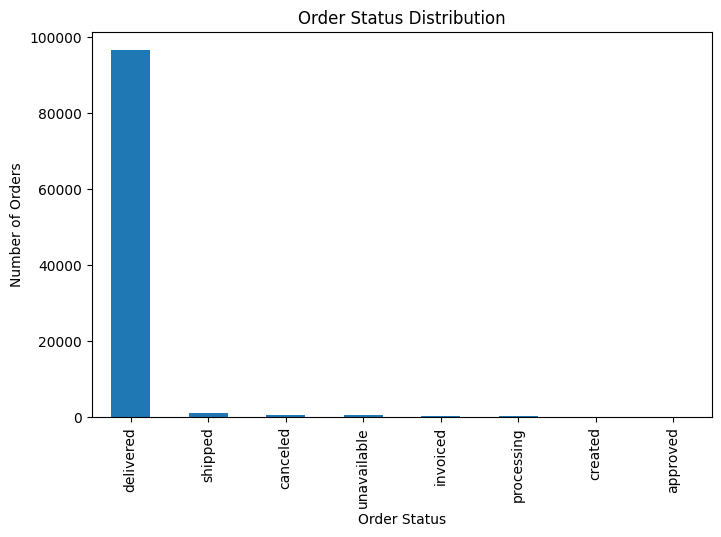

In [6]:
# HOW ARE ORDERS DISTRIBUTED BY STATUS?
status = (
    orders["order_status"]
    .value_counts()
    .sort_values(ascending=False)
)

print(status)

status.plot(kind="bar", figsize=(8,5))

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.show()

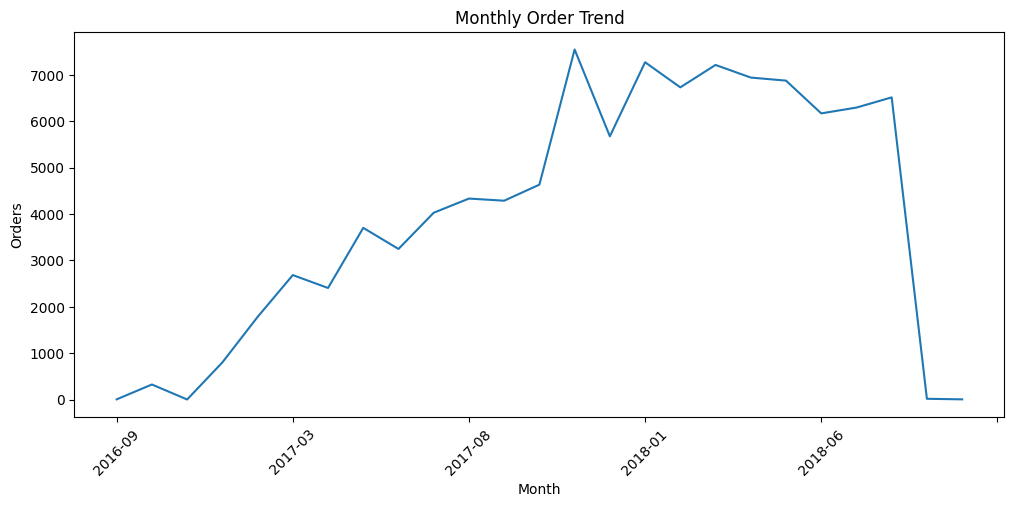

In [7]:
# HOW DO ORDERS CHANGE OVER TIME?
orders["YearMonth"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

monthly_orders = (
    orders.groupby("YearMonth")
    .size()
)

monthly_orders.plot(figsize=(12,5))

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)

plt.show()

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64


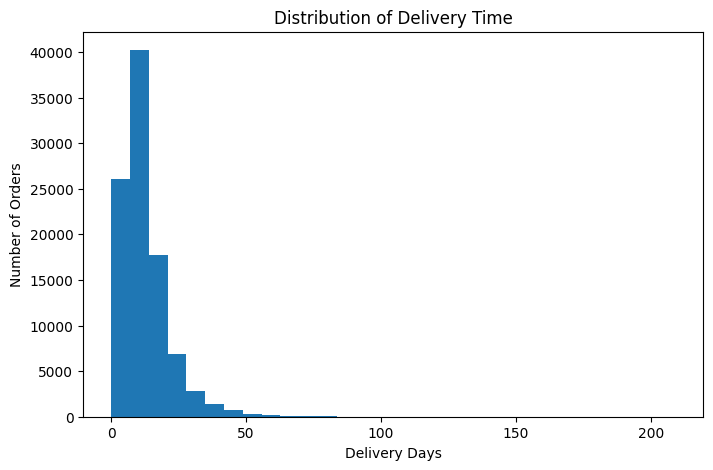

In [8]:
# WHAT IS THE AVERAGE DELIVERY TIME?
delivered_orders = orders[
    orders["order_status"] == "delivered"
].copy()

delivered_orders["delivery_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_purchase_timestamp"]
).dt.days

print(delivered_orders["delivery_days"].describe())

plt.figure(figsize=(8,5))
plt.hist(delivered_orders["delivery_days"].dropna(), bins=30)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")
plt.show()

In [9]:
# WERE ORDERS DELIVERED ON TIME?
orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

delivered = orders[
    orders["order_status"] == "delivered"
].copy()

delivered["late_delivery"] = (
    delivered["order_delivered_customer_date"]
    >
    delivered["order_estimated_delivery_date"]
)

late_counts = delivered["late_delivery"].value_counts()

print(late_counts)

late_percentage = (
    delivered["late_delivery"].mean()
) * 100

print(f"Late Deliveries: {late_percentage:.2f}%")

late_delivery
False    88652
True      7826
Name: count, dtype: int64
Late Deliveries: 8.11%


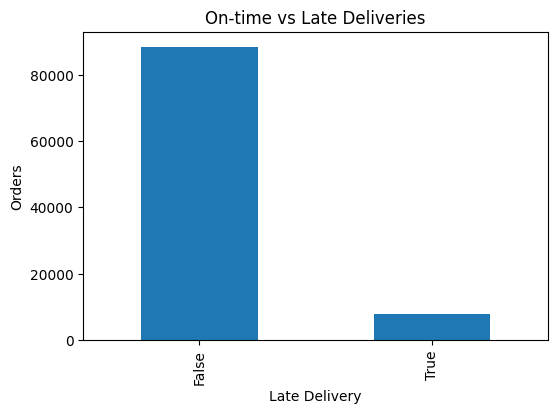

In [10]:
late_counts.plot(kind="bar", figsize=(6,4))

plt.title("On-time vs Late Deliveries")
plt.xlabel("Late Delivery")
plt.ylabel("Orders")

plt.show()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


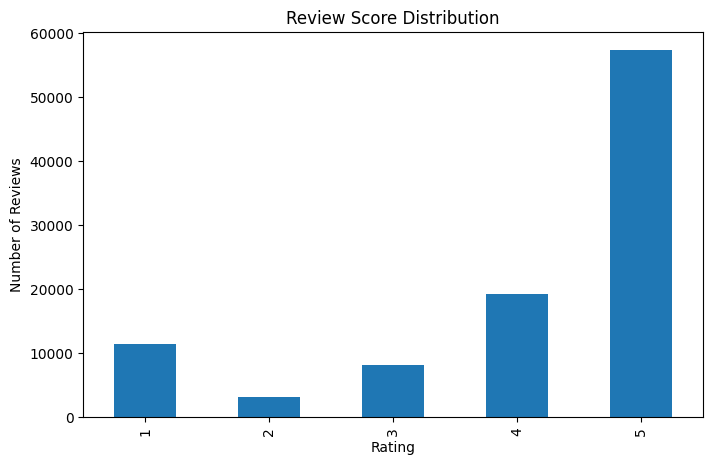

In [11]:
# WHAT IS THE DISTRIBUTION OF REVIEW SCORES?
review_counts = reviews["review_score"].value_counts().sort_index()

print(review_counts)

review_counts.plot(kind="bar", figsize=(8,5))

plt.title("Review Score Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

In [12]:
# WHAT IS THE AVERAGE REVIEW SCORE?
average_rating = reviews["review_score"].mean()

print(f"Average Review Score: {average_rating:.2f}")

Average Review Score: 4.09


In [13]:
# WHAT ARE THE MOST COMMON REVIEW TITLES?
reviews["review_comment_title"] = (
    reviews["review_comment_title"]
    .fillna("No Title")
)

top_titles = (
    reviews["review_comment_title"]
    .value_counts()
    .head(15)
)

print(top_titles)

review_comment_title
No Title           87656
Recomendo            423
recomendo            345
Bom                  293
super recomendo      270
Excelente            248
Muito bom            247
Ótimo                240
Super recomendo      217
Ótimo                207
Otimo                174
10                   158
Excelente            119
otimo                105
bom                   97
Name: count, dtype: int64


seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
MS       5
RN       5
MT       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64


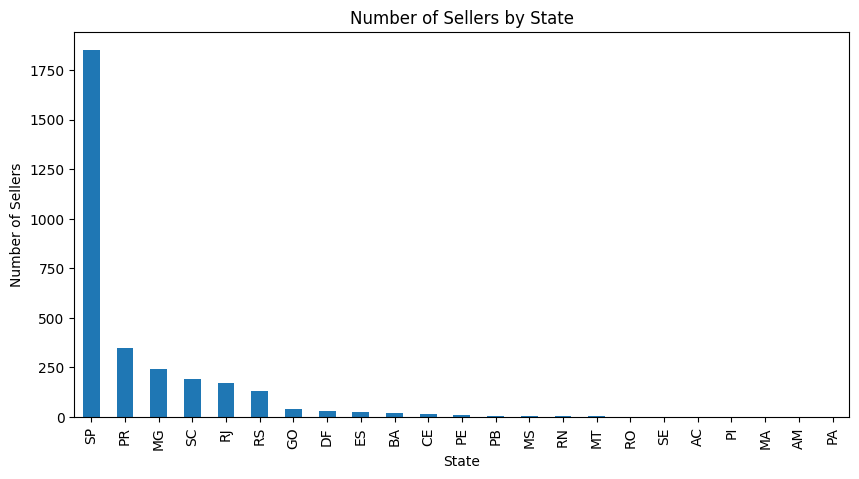

In [14]:
# WHICH STATES HAVE THE MOST SELLERS?
seller_state = (
    sellers["seller_state"]
    .value_counts()
    .sort_values(ascending=False)
)

print(seller_state)

plt.figure(figsize=(10,5))
seller_state.plot(kind="bar")

plt.title("Number of Sellers by State")
plt.xlabel("State")
plt.ylabel("Number of Sellers")

plt.show()

seller_city
Sao Paulo         694
Curitiba          127
Rio De Janeiro     96
Belo Horizonte     68
Ribeirao Preto     52
Guarulhos          50
Ibitinga           49
Santo Andre        45
Campinas           41
Maringa            40
Name: count, dtype: int64


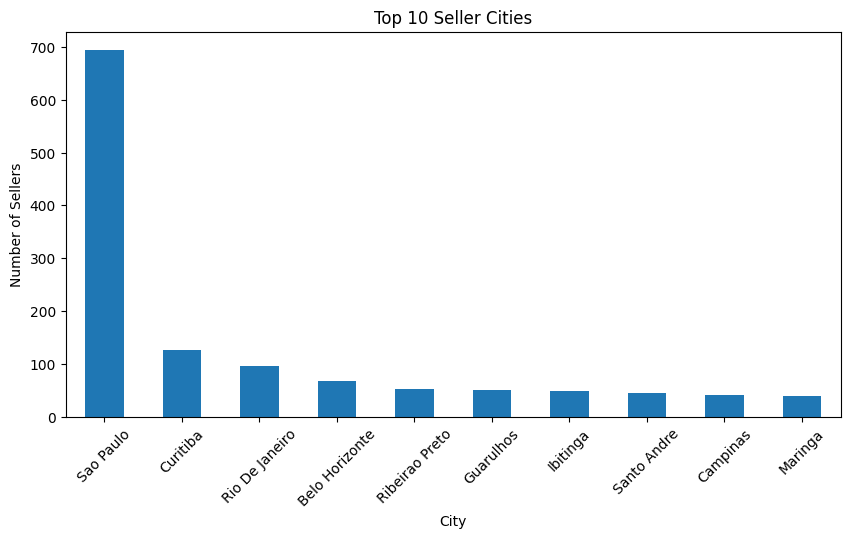

In [15]:
# Top 10 Seller Cities
top_cities = (
    sellers["seller_city"]
    .value_counts()
    .head(10)
)

print(top_cities)

plt.figure(figsize=(10,5))
top_cities.plot(kind="bar")

plt.title("Top 10 Seller Cities")
plt.xlabel("City")
plt.ylabel("Number of Sellers")

plt.xticks(rotation=45)

plt.show()

In [16]:
# SELLER DISTRIBUTION PERCENTAGE
seller_percent = (
    sellers["seller_state"]
    .value_counts(normalize=True)
    *100
).round(2)

print(seller_percent)

seller_state
SP    59.74
PR    11.28
MG     7.88
SC     6.14
RJ     5.53
RS     4.17
GO     1.29
DF     0.97
ES     0.74
BA     0.61
CE     0.42
PE     0.29
PB     0.19
MS     0.16
RN     0.16
MT     0.13
RO     0.06
SE     0.06
AC     0.03
PI     0.03
MA     0.03
AM     0.03
PA     0.03
Name: proportion, dtype: float64


In [17]:
# AVERAGE REVIEW SCORE BY RATING
review_summary = (
    reviews.groupby("review_score")
    .size()
    .reset_index(name="Total Reviews")
)

print(review_summary)

   review_score  Total Reviews
0             1          11424
1             2           3151
2             3           8179
3             4          19142
4             5          57328


In [18]:
# REVIEW SCORE PERCENTAGE
review_percentage = (
    reviews["review_score"]
    .value_counts(normalize=True)
    .sort_index()*100
).round(2)

print(review_percentage)

review_score
1    11.51
2     3.18
3     8.24
4    19.29
5    57.78
Name: proportion, dtype: float64


In [19]:
# REVIEW COMMENT AVAILIBILITY
comment_stats = pd.DataFrame({
    "With Comment":[reviews["review_comment_message"].notna().sum()],
    "Without Comment":[reviews["review_comment_message"].isna().sum()]
})

print(comment_stats)

   With Comment  Without Comment
0         99224                0


count    99224.000000
mean         2.582248
std          9.890526
min          0.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        518.000000
Name: response_time, dtype: float64


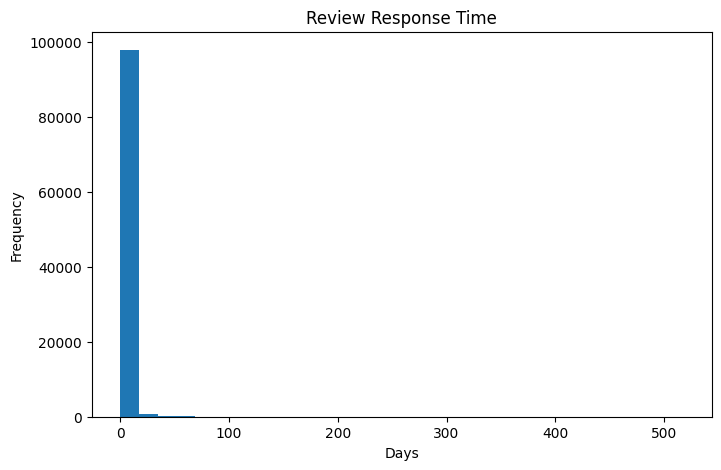

In [20]:
# AVERAGE REVIEW RESPONSE TIME
reviews["response_time"] = (
    reviews["review_answer_timestamp"]
    - reviews["review_creation_date"]
).dt.days

print(reviews["response_time"].describe())

plt.figure(figsize=(8,5))

plt.hist(reviews["response_time"].dropna(), bins=30)

plt.title("Review Response Time")
plt.xlabel("Days")
plt.ylabel("Frequency")

plt.show()

In [21]:
# SELLER LOCATION MAP PREPARATION

seller_geo = (
    sellers.merge(
        geolocation,
        left_on="seller_zip_code_prefix",
        right_on="geolocation_zip_code_prefix",
        how="left"
    )
)

seller_geo.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,3442f8959a84dea7ee197c632cb2df15,13023,Campinas,SP,13023.0,-22.898536,-47.063125,Campinas,SP
1,3442f8959a84dea7ee197c632cb2df15,13023,Campinas,SP,13023.0,-22.895499,-47.061944,Campinas,SP
2,3442f8959a84dea7ee197c632cb2df15,13023,Campinas,SP,13023.0,-22.891740,-47.060820,Campinas,SP
3,3442f8959a84dea7ee197c632cb2df15,13023,Campinas,SP,13023.0,-22.895762,-47.066144,Campinas,SP
4,3442f8959a84dea7ee197c632cb2df15,13023,Campinas,SP,13023.0,-22.896154,-47.062431,Campinas,SP


In [22]:
# NUMBER OF SELLER LOCATIONS
seller_geo.groupby("seller_state")[
    "seller_id"
].count().sort_values(ascending=False)

,seller_id
seller_state,
SP,171861
MG,47784
PR,31751
RJ,19523
SC,18583
RS,13396
GO,1978
BA,1821
ES,1672


In [23]:
# GEOGRAPHIC COORDINATES SUMMARY
seller_geo[
    [
        "geolocation_lat",
        "geolocation_lng"
    ]
].describe()

,geolocation_lat,geolocation_lng
count,311789.000000,311789.000000
mean,-22.871844,-47.333297
std,2.840552,2.766167
min,-36.605374,-67.884719
25%,-23.644279,-48.848391
50%,-22.946903,-47.152262
75%,-21.602020,-46.410711
max,-2.484892,-34.847687


In [24]:
# DO LATE DELIVERIES RESULT IN LOWER REVIEW SCORES?

orders_reviews = orders.merge(
    reviews,
    on="order_id",
    how="inner"
)
orders_reviews.head()

orders_reviews["delivery_days"] = (
    orders_reviews["order_delivered_customer_date"]
    - orders_reviews["order_purchase_timestamp"]
).dt.days

delivery_vs_rating = (
    orders_reviews
    .groupby("review_score")["delivery_days"]
    .mean()
    .round(2)
)

print(delivery_vs_rating)


review_score
1    20.85
2    16.19
3    13.80
4    11.85
5    10.22
Name: delivery_days, dtype: float64


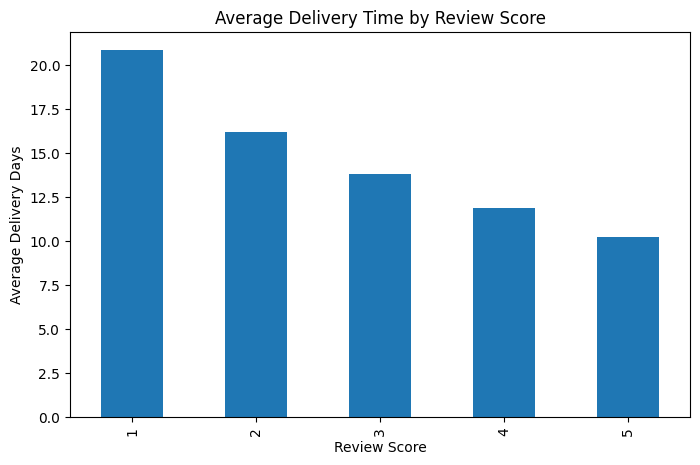

In [25]:
delivery_vs_rating.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Delivery Time by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Days")

plt.show()

late_delivery
False    4.214307
True     2.566550
Name: review_score, dtype: float64


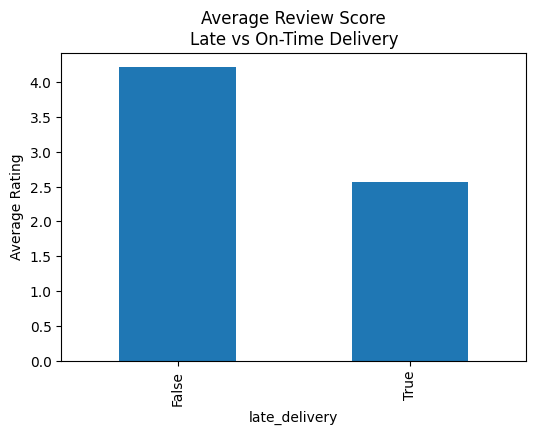

In [26]:
# ARE LATE DELIVERIES ASSOCIATED WITH POOR RATINGS?
orders_reviews["late_delivery"] = (
    orders_reviews["order_delivered_customer_date"]
    >
    orders_reviews["order_estimated_delivery_date"]
)

late_rating = (
    orders_reviews
    .groupby("late_delivery")["review_score"]
    .mean()
)

print(late_rating)

late_rating.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Average Review Score\nLate vs On-Time Delivery")
plt.ylabel("Average Rating")

plt.show()

order_status
processing     1.277027
unavailable    1.530988
invoiced       1.661342
canceled       1.811166
shipped        2.008629
created        2.333333
approved       2.500000
delivered      4.155717
Name: review_score, dtype: float64


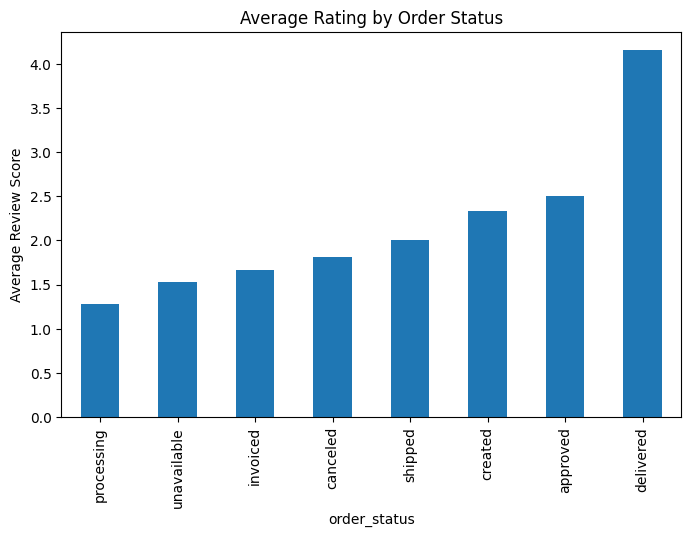

In [27]:
# WHICH ORDER STATUSES RECEIVE THE LOWEST RATINGS?
status_rating = (
    orders_reviews
    .groupby("order_status")["review_score"]
    .mean()
    .sort_values()
)

print(status_rating)

status_rating.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Rating by Order Status")
plt.ylabel("Average Review Score")

plt.show()

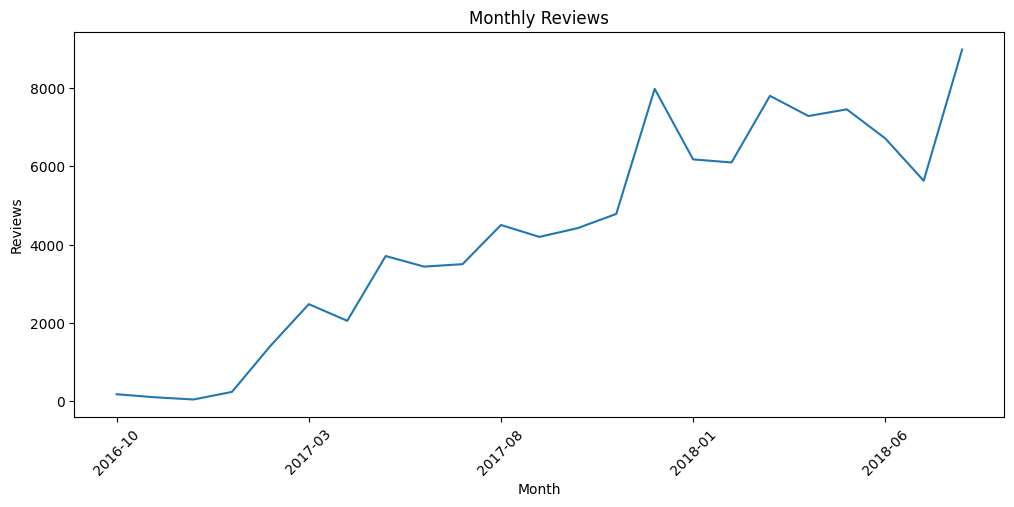

In [28]:
# MONTHLY REVIEW TREND
orders_reviews["Month"] = (
    orders_reviews["review_creation_date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_reviews = (
    orders_reviews
    .groupby("Month")
    .size()
)

monthly_reviews.plot(
    figsize=(12,5)
)

plt.title("Monthly Reviews")
plt.ylabel("Reviews")

plt.xticks(rotation=45)

plt.show()

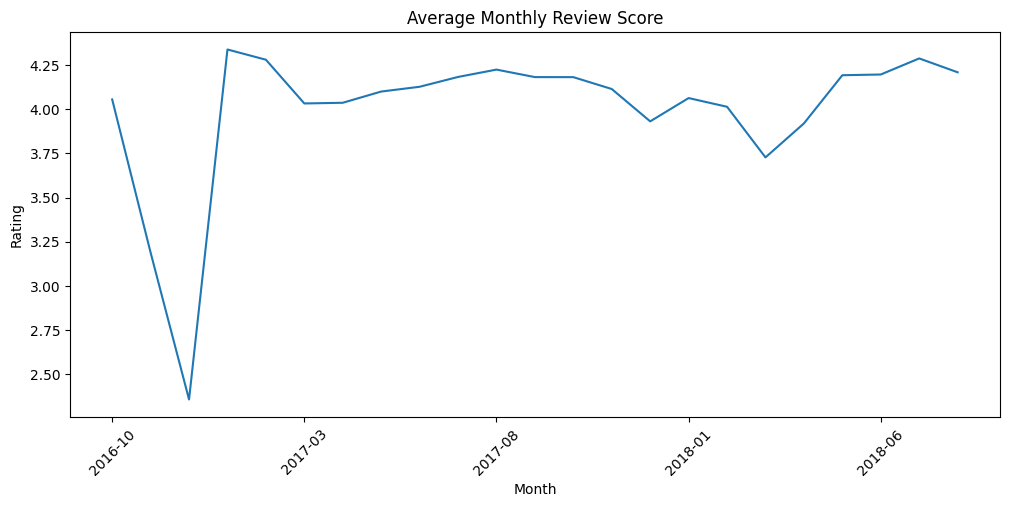

In [29]:
# REVIEW SCORE DISTRIBUTION BY MONTH
monthly_rating = (
    orders_reviews
    .groupby("Month")["review_score"]
    .mean()
)

monthly_rating.plot(
    figsize=(12,5)
)

plt.title("Average Monthly Review Score")
plt.ylabel("Rating")

plt.xticks(rotation=45)

plt.show()

In [30]:
# DELIVERY TIME CATEGORIES
orders_reviews["Delivery_Category"] = pd.cut(
    orders_reviews["delivery_days"],
    bins=[0,3,7,14,30,100],
    labels=[
        "0-3 Days",
        "4-7 Days",
        "8-14 Days",
        "15-30 Days",
        "30+ Days"
    ]
)

delivery_category = (
    orders_reviews["Delivery_Category"]
    .value_counts()
)

print(delivery_category)

Delivery_Category
8-14 Days     36396
4-7 Days      25089
15-30 Days    22246
0-3 Days       8583
30+ Days       3972
Name: count, dtype: int64


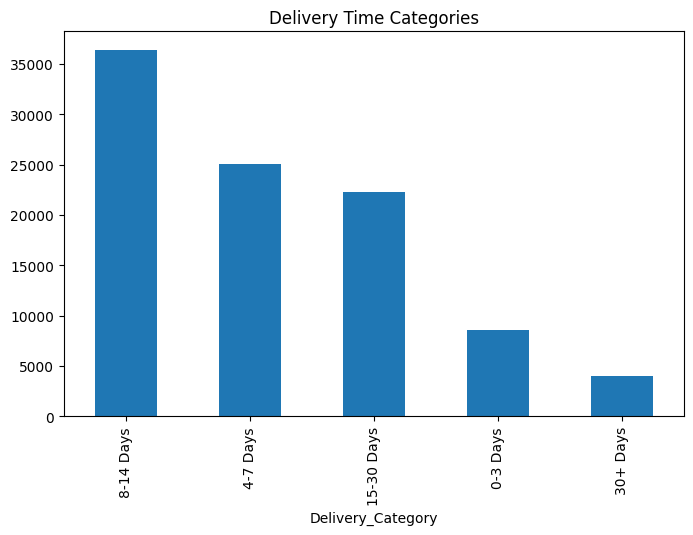

In [31]:
delivery_category.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Delivery Time Categories")

plt.show()

Delivery_Category
0-3 Days      4.460329
4-7 Days      4.390490
8-14 Days     4.288356
15-30 Days    3.914591
30+ Days      2.164653
Name: review_score, dtype: float64


/tmp/ipykernel_518/3259870774.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Delivery_Category")["review_score"]


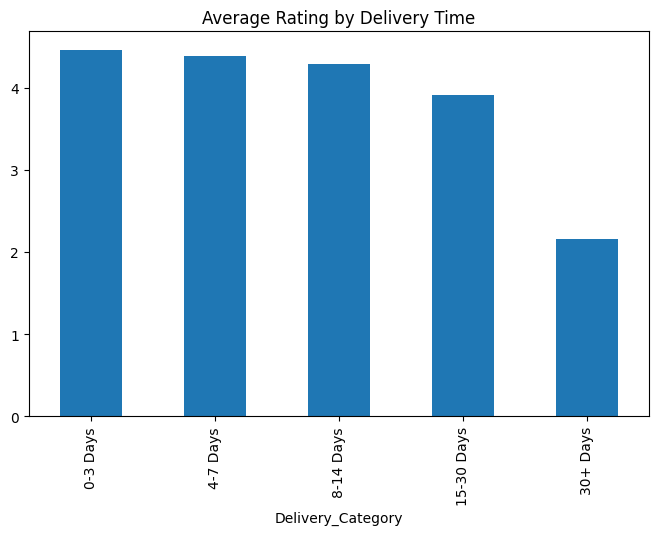

In [32]:
# AVERAGE REVIEW SCORE BY DELIVERY CATEGORY
category_rating = (
    orders_reviews
    .groupby("Delivery_Category")["review_score"]
    .mean()
)

print(category_rating)

category_rating.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Rating by Delivery Time")

plt.show()

In [33]:
# EXECUTIVE KPI TABLE
kpi = pd.DataFrame({

    "Metric":[
        "Total Orders",
        "Delivered Orders",
        "Average Delivery Days",
        "Late Deliveries (%)",
        "Average Rating"
    ],

    "Value":[

        len(orders),

        (orders["order_status"]=="delivered").sum(),

        round(
            orders_reviews["delivery_days"].mean(),2
        ),

        round(
            orders_reviews["late_delivery"].mean()*100,2
        ),

        round(
            reviews["review_score"].mean(),2
        )

    ]
})
kpi

,Metric,Value
0,Total Orders,99441.00
1,Delivered Orders,96478.00
2,Average Delivery Days,12.06
3,Late Deliveries (%),7.76
4,Average Rating,4.09
